In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
# Load the data
file_path = '/home/reitumetse/Downloads/youth_unemployment.csv'
data = pd.read_csv(file_path)

# Checking for missing values
print("Missing values per column:\n", data.isnull().sum())

# Fill missing values or drop rows/columns as necessary (handling this as needed)
# For simplicity, let's drop any rows with missing values
data.dropna(inplace=True)

# Convert categorical data to numerical values using LabelEncoder
label_encoders = {}
for column in ['Gender', 'Location', 'Highest Qualification', 'Field of Study', 
               'Employment Status', 'Technical Skills', 'Soft Skills', 'Certification']:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

# Splitting data into features (X) and target (y)
X = data.drop(['ID', 'Employment Status'], axis=1)  # Features
y = data['Employment Status']  # Target

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Missing values per column:
 ID                         0
Age                        0
Gender                     0
Location                   0
Highest Qualification      0
Field of Study             0
Employment Status          0
Technical Skills         147
Soft Skills              161
Certification              0
dtype: int64


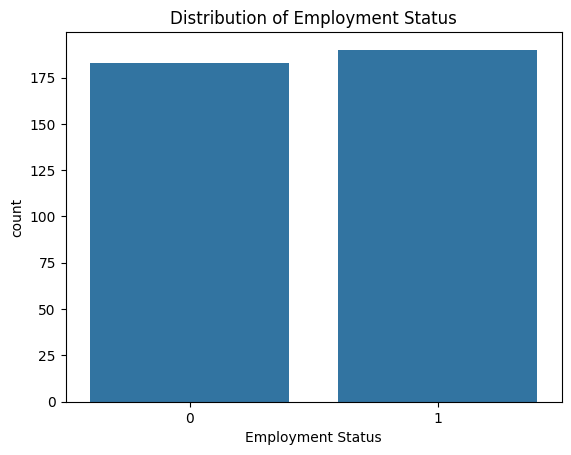

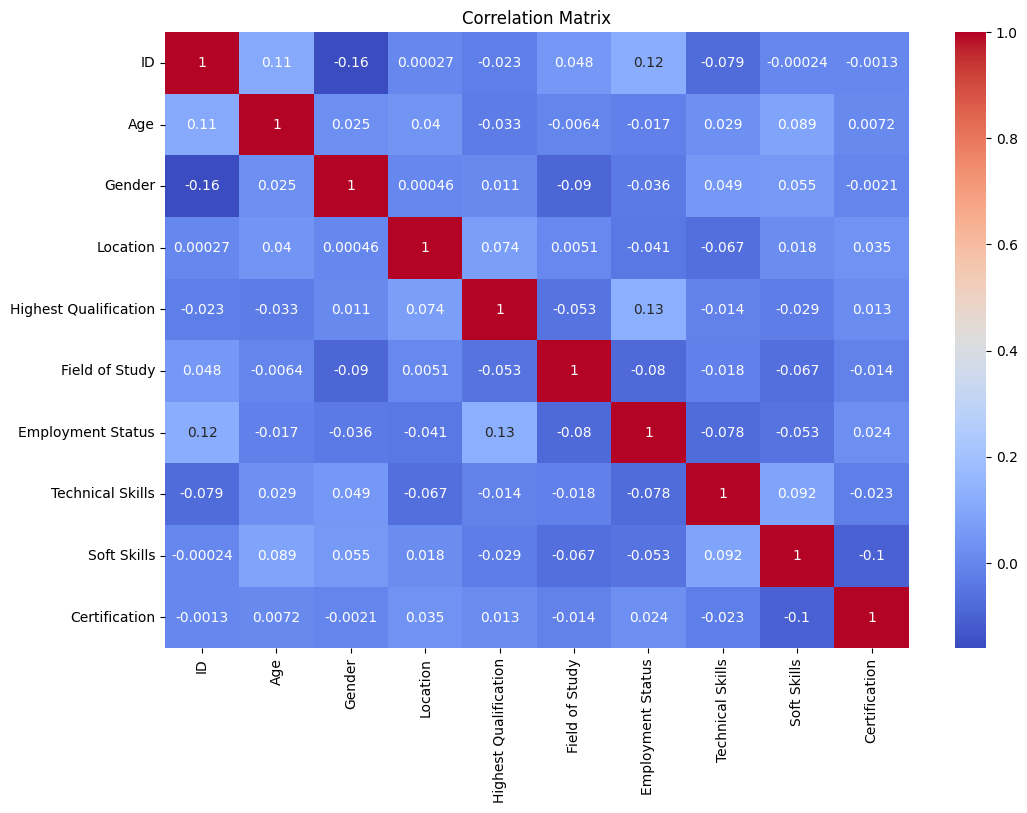

In [3]:
# Plot the distribution of employability
sns.countplot(x='Employment Status', data=data)
plt.title('Distribution of Employment Status')
plt.show()

# Correlation matrix to see how features relate to employability
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [4]:
from sklearn.svm import SVC

svc_classifier = SVC(kernel = 'linear' , random_state = 42)

svc_classifier.fit(X_train , y_train)

SVC(kernel='linear', random_state=42)

Accuracy: 0.37333333333333335
Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.24      0.28        38
           1       0.40      0.51      0.45        37

    accuracy                           0.37        75
   macro avg       0.36      0.38      0.36        75
weighted avg       0.36      0.37      0.36        75



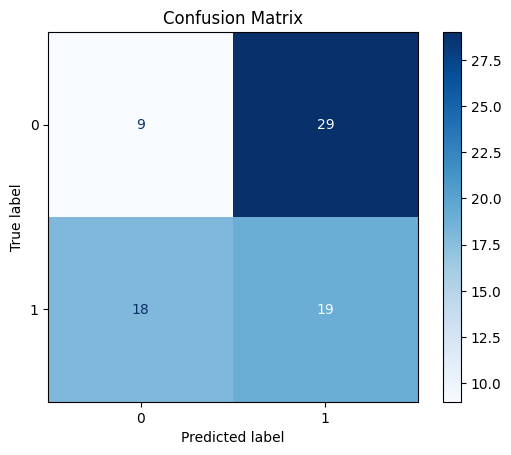

In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix , ConfusionMatrixDisplay

# Predict on the test data
y_pred = svc_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print accuracy and classification report
print(f"Accuracy: {accuracy}")
print(f"Classification Report:\n{report}")

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix = conf_matrix , display_labels = svc_classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

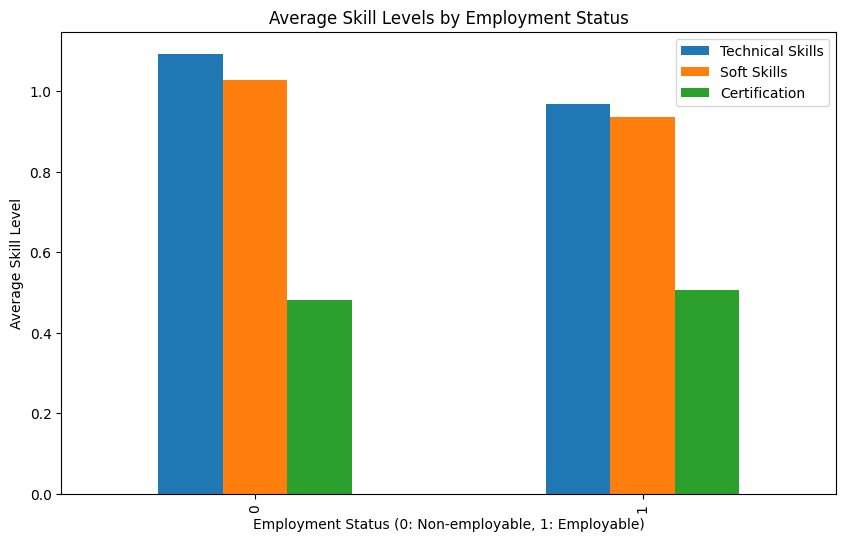

Recommendations:
1. Enhance Technical Skills: Focus on technical training programs to improve employability.
2. Improve Soft Skills: Workshops on communication, teamwork, and problem-solving.
3. Increase Certifications: Encourage obtaining relevant certifications to boost qualifications.


In [6]:
# Identify employable vs. non-employable individuals
employable = data[data['Employment Status'] == 1]
non_employable = data[data['Employment Status'] == 0]

# Analyze what skills non-employable individuals lack
# Compare average skill levels between employable and non-employable groups
skills_comparison = data.groupby('Employment Status').mean()[['Technical Skills', 'Soft Skills', 'Certification']]

# Visualize the skill gaps
skills_comparison.plot(kind='bar', figsize=(10, 6))
plt.title('Average Skill Levels by Employment Status')
plt.xlabel('Employment Status (0: Non-employable, 1: Employable)')
plt.ylabel('Average Skill Level')
plt.show()

# Output recommendations based on the observed gaps
print("Recommendations:")
print("1. Enhance Technical Skills: Focus on technical training programs to improve employability.")
print("2. Improve Soft Skills: Workshops on communication, teamwork, and problem-solving.")
print("3. Increase Certifications: Encourage obtaining relevant certifications to boost qualifications.")

In [7]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

In [8]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check the new class distribution
print(pd.Series(y_train_res).value_counts())

Employment Status
0    153
1    153
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define the parameter grid
param_grid = {
    'C': [10, 100],
    'gamma': [0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

# Initialize GridSearchCV
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3, cv=8)
grid.fit(X_train_res, y_train_res)

# Print the best parameters found by GridSearchCV
print(f"Best Parameters: {grid.best_params_}")

# Use the best model
best_model = grid.best_estimator_

# Evaluate on the test set
y_pred = best_model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
print(f"Accuracy: {accuracy}")

Fitting 8 folds for each of 12 candidates, totalling 96 fits
[CV 1/8] END ......C=10, gamma=0.01, kernel=rbf;, score=0.487 total time=   0.0s
[CV 2/8] END ......C=10, gamma=0.01, kernel=rbf;, score=0.513 total time=   0.0s
[CV 3/8] END ......C=10, gamma=0.01, kernel=rbf;, score=0.579 total time=   0.0s
[CV 4/8] END ......C=10, gamma=0.01, kernel=rbf;, score=0.526 total time=   0.0s
[CV 5/8] END ......C=10, gamma=0.01, kernel=rbf;, score=0.553 total time=   0.0s
[CV 6/8] END ......C=10, gamma=0.01, kernel=rbf;, score=0.474 total time=   0.0s
[CV 7/8] END ......C=10, gamma=0.01, kernel=rbf;, score=0.553 total time=   0.0s
[CV 8/8] END ......C=10, gamma=0.01, kernel=rbf;, score=0.658 total time=   0.0s
[CV 1/8] END .....C=10, gamma=0.01, kernel=poly;, score=0.513 total time=  11.8s
[CV 2/8] END .....C=10, gamma=0.01, kernel=poly;, score=0.538 total time=  14.2s
[CV 3/8] END .....C=10, gamma=0.01, kernel=poly;, score=0.526 total time=   7.5s
[CV 4/8] END .....C=10, gamma=0.01, kernel=poly;

/home/reitumetse/.local/lib/python3.10/site-packages/numpy/ma/core.py:2820: RuntimeWarning:

invalid value encountered in cast



In [10]:
!pip install dash

Defaulting to user installation because normal site-packages is not writeable


In [11]:
import dash
from dash import dcc, html, Input, Output, State
import pandas as pd

# Load the CSV file
file_path = "/home/reitumetse/Downloads/youth_unemployment.csv"
data = pd.read_csv(file_path)

# Extract unique options for highest qualification, skills, and certifications
qualifications = data['Highest Qualification'].unique().tolist()
qualifications.extend(['Honours', 'Masters', 'Doctorate'])
qualifications = list(set(qualifications))  # Remove duplicates

# Extract technical skills and certifications, filtering out null values
skills = data['Technical Skills'].unique().tolist()
skills = [s for s in skills if pd.notnull(s)]

certifications = data['Certification'].unique().tolist()

# Define additional fields of study
fields_of_study = [
    'Arts', 'Science', 'Commerce', 'Engineering', 'Health Sciences',
    'Information Technology', 'Education', 'Social Sciences', 'Environmental Science', 
    'Mathematics', 'Anthropology', 'History', 'Linguistics and languages', 
    'Philosophy', 'Religion', 'Culinary', 'Economics', 'Geography', 
    'Political Science', 'Psychology', 'Biology', 'Chemistry', 
    'Earth Science', 'Physics', 'Computer Science', 'Agriculture', 
    'Architecture and Design', 'Business', 'Human Sports Science', 
    'Law', 'Journalism', 'HR', 'Media', 'Tourism'
]

south_african_cities = [
    'Johannesburg', 'Cape Town', 'Durban', 'Pretoria', 'Port Elizabeth',
    'Bloemfontein', 'Pietermaritzburg', 'Kimberley', 'East London',
    'Nelspruit', 'Polokwane', 'Tshwane', 'Mahikeng', 'Richards Bay', 'Illovo',
    'George', 'Vanderbijlpark', 'Umlazi', 'Soweto', 'Newcastle', 'Seshego',
    'Burgersfort', 'Secunda', 'Parys', 'Krugersdorp', 'Ceres', 'Mthatha', 'Giyani', 'Warrenton'
]

# Define rural areas and their corresponding cities
rural_to_city = {
    'Mahikeng': 'Johannesburg',
    'Parys': 'Bloemfontein',
    'Burgersfort': 'Nelspruit',
    'Secunda': 'Nelspruit',
    'Mthatha': 'East London',
    'Umlazi': 'Durban',
    'Illovo': 'Pietermaritzburg',
    'Seshego': 'Polokwane',
    'Giyani': 'Tzaneen',
    'Upington': 'Upington',
    'Warrenton': 'Kimberley',
    'Ceres': 'Cape Town',
    'Paternoster': 'Cape Town'
}

# Create the Dash app with external stylesheets
app = dash.Dash(__name__, external_stylesheets=["https://stackpath.bootstrapcdn.com/bootstrap/4.5.2/css/bootstrap.min.css"])

# Define additional soft skills
soft_skills = [
    'Problem-Solving',
    'Communication',
    'Teamwork',
    'Adaptability',
    'Critical Thinking',
    'Leadership',
    'Time Management',
    'Creativity',
    'Conflict Resolution',
    'Negotiation',
    'Emotional Intelligence',
    'Active Listening',
    'Collaboration'
]

# Define recommendations based on soft skills
soft_skill_recommendations = {
    'Problem-Solving': ["Analyst", "Consultant", "Project Manager"],
    'Communication': ["Customer Service Representative", "Sales Associate", "Public Relations Specialist"],
    'Teamwork': ["Project Coordinator", "Event Planner", "Human Resources Specialist"],
    'Adaptability': ["Freelancer", "Entrepreneur", "Consultant"],
    'Critical Thinking': ["Data Analyst", "Researcher", "Strategist"],
    'Leadership': ["Manager", "Team Leader", "Project Manager"],
    'Time Management': ["Administrative Assistant", "Scheduler", "Event Coordinator"],
    'Creativity': ["Graphic Designer", "Marketing Specialist", "Content Creator"],
    'Conflict Resolution': ["Mediator", "Human Resources Specialist", "Customer Service Representative"],
    'Negotiation': ["Sales Representative", "Purchasing Agent", "Real Estate Agent"],
    'Emotional Intelligence': ["Counselor", "Social Worker", "Human Resources Specialist"],
    'Active Listening': ["Counselor", "Customer Service Representative", "Teacher"],
    'Collaboration': ["Project Manager", "Team Leader", "Event Coordinator"]
}

app.layout = html.Div(style={'backgroundColor': 'black', 'color': 'pink'}, className='container', children=[
    html.Div([
        html.H1("Youth Employment Recommendation System", className='text-center my-4'),
        html.Label("Age:", className='form-label'),
        dcc.Input(
            id='age',
            type='number',
            value=18,
            min=18,
            max=35,
            step=1,
            className='form-control mb-3'
        ),
        html.Label("Gender:", className='form-label'),
        dcc.RadioItems(
            id='gender',
            options=[{'label': 'Male', 'value': 'Male'},
                     {'label': 'Female', 'value': 'Female'},
                     {'label': 'Rather not say', 'value': 'Rather not say'}],
            value='Male',
            inline=True,
            className='mb-3'
        ),
        html.Label("Residence:", className='form-label'),
        dcc.Dropdown(
            id='residence',
            options=[{'label': city, 'value': city} for city in south_african_cities],
            value='Johannesburg',
            className='form-select mb-3'
        ),
        html.Label("Highest Qualification:", className='form-label'),
        dcc.Dropdown(
            id='qualification',
            options=[{'label': q, 'value': q} for q in qualifications],
            value=qualifications[0] if qualifications else '',
            className='form-select mb-3'
        ),
        html.Label("Field of Study:", className='form-label'),
        dcc.Dropdown(
            id='field_of_study',
            options=[{'label': f, 'value': f} for f in fields_of_study],
            value=fields_of_study[0] if fields_of_study else '',
            className='form-select mb-3'
        ),
        html.Label("Technical Skills:", className='form-label'),
        dcc.Dropdown(
            id='skills',
            options=[{'label': s, 'value': s} for s in skills],
            value=[skills[0]] if skills else [],
            multi=True,
            className='form-select mb-3'
        ),
        html.Label("Soft Skills:", className='form-label'),
        dcc.Dropdown(
            id='soft_skills',
            options=[{'label': s, 'value': s} for s in soft_skills],
            value=[soft_skills[0]] if soft_skills else [],
            multi=True,
            className='form-select mb-3'
        ),
        html.Label("Certification:", className='form-label'),
        dcc.Dropdown(
            id='certifications',
            options=[{'label': c, 'value': c} for c in certifications],
            value=[certifications[0]] if certifications else [],
            multi=True,
            className='form-select mb-3'
        ),
        html.Button('Submit', id='submit-button', n_clicks=0, className='btn btn-primary mt-3'),
        html.Div(id='recommendation', className='mt-4'),
        html.Div(id='error-message', style={'color': 'red'})
    ])
])

@app.callback(
    Output('error-message', 'children'),
    [Input('submit-button', 'n_clicks')],
    [State('age', 'value')]
)
def validate_age(n_clicks, age):
    if n_clicks > 0:
        if age is None or age > 35:
            return "Error: You are not part of the South African youth. Please enter an age between 18 and 35."
    return ""  # No error message if age is valid

@app.callback(
    Output('recommendation', 'children'),
    [Input('submit-button', 'n_clicks')],
    [State('age', 'value'),
     State('gender', 'value'),
     State('residence', 'value'),
     State('qualification', 'value'),
     State('field_of_study', 'value'),
     State('skills', 'value'),
     State('soft_skills', 'value'),
     State('certifications', 'value')]
)
def provide_recommendation(n_clicks, age, gender, residence, qualification, field_of_study, skills, soft_skills, certifications):
    if n_clicks > 0:
        if age is None or age > 35:
            return ""  # Skip recommendation if age is invalid

        # Check if the user is less than 21
        if age < 21:
            return "You should consider gaining more experience in your career."

        # Check if the residence is a rural area
        if residence in rural_to_city:
            residence = rural_to_city[residence]

        # Filter recommendations based on soft skills
        recommended_jobs = []
        for skill in soft_skills:
            if skill in soft_skill_recommendations:
                recommended_jobs.extend(soft_skill_recommendations[skill])

        return f"Recommended Jobs based on your skills and preferences: {', '.join(set(recommended_jobs))}"
    return ""  # No recommendation if the button hasn't been clicked

if __name__ == '__main__':
    app.run_server(debug=True)

In [2]:
import dash
from dash import dcc, html, Input, Output, State
import pandas as pd

# Load the CSV file
file_path = "/home/reitumetse/Downloads/youth_unemployment.csv"
data = pd.read_csv(file_path)

# Extract unique options for highest qualification, skills, and certifications
qualifications = data['Highest Qualification'].unique().tolist()
qualifications.extend(['Honours', 'Masters', 'Doctorate'])
qualifications = list(set(qualifications))  # Remove duplicates

# Extract technical skills and certifications, filtering out null values
skills = data['Technical Skills'].unique().tolist()
skills = [s for s in skills if pd.notnull(s)]

certifications = data['Certification'].unique().tolist()

# Define additional fields of study
fields_of_study = [
    'Arts', 'Science', 'Commerce', 'Engineering', 'Health Sciences',
    'Information Technology', 'Education', 'Social Sciences', 'Environmental Science', 
    'Mathematics', 'Anthropology', 'History', 'Linguistics and languages', 
    'Philosophy', 'Religion', 'Culinary', 'Economics', 'Geography', 
    'Political Science', 'Psychology', 'Biology', 'Chemistry', 
    'Earth Science', 'Physics', 'Computer Science', 'Agriculture', 
    'Architecture and Design', 'Business', 'Human Sports Science', 
    'Law', 'Journalism', 'HR', 'Media', 'Tourism'
]

south_african_cities = [
    'Johannesburg', 'Cape Town', 'Durban', 'Pretoria', 'Port Elizabeth',
    'Bloemfontein', 'Pietermaritzburg', 'Kimberley', 'East London',
    'Nelspruit', 'Polokwane', 'Tshwane', 'Mahikeng', 'Richards Bay', 'Illovo',
    'George', 'Vanderbijlpark', 'Umlazi', 'Soweto', 'Newcastle', 'Seshego',
    'Burgersfort', 'Secunda', 'Parys', 'Krugersdorp', 'Ceres', 'Mthatha', 'Giyani', 'Warrenton'
]

# Define rural areas and their corresponding cities
rural_to_city = {
    'Mahikeng': 'Johannesburg',
    'Parys': 'Bloemfontein',
    'Burgersfort': 'Nelspruit',
    'Secunda': 'Nelspruit',
    'Mthatha': 'East London',
    'Umlazi': 'Durban',
    'Illovo': 'Pietermaritzburg',
    'Seshego': 'Polokwane',
    'Giyani': 'Tzaneen',
    'Upington': 'Upington',
    'Warrenton': 'Kimberley',
    'Ceres': 'Cape Town',
    'Paternoster': 'Cape Town'
}

# Create the Dash app with external stylesheets
app = dash.Dash(__name__, external_stylesheets=["https://stackpath.bootstrapcdn.com/bootstrap/4.5.2/css/bootstrap.min.css"])

# Define additional soft skills
soft_skills = [
    'Problem-Solving',
    'Communication',
    'Teamwork',
    'Adaptability',
    'Critical Thinking',
    'Leadership',
    'Time Management',
    'Creativity',
    'Conflict Resolution',
    'Negotiation',
    'Emotional Intelligence',
    'Active Listening',
    'Collaboration'
]

# Define recommendations based on soft skills
soft_skill_recommendations = {
    'Problem-Solving': ["Analyst", "Consultant", "Project Manager"],
    'Communication': ["Customer Service Representative", "Sales Associate", "Public Relations Specialist"],
    'Teamwork': ["Project Coordinator", "Event Planner", "Human Resources Specialist"],
    'Adaptability': ["Freelancer", "Entrepreneur", "Consultant"],
    'Critical Thinking': ["Data Analyst", "Researcher", "Strategist"],
    'Leadership': ["Manager", "Team Leader", "Project Manager"],
    'Time Management': ["Administrative Assistant", "Scheduler", "Event Coordinator"],
    'Creativity': ["Graphic Designer", "Marketing Specialist", "Content Creator"],
    'Conflict Resolution': ["Mediator", "Human Resources Specialist", "Customer Service Representative"],
    'Negotiation': ["Sales Representative", "Purchasing Agent", "Real Estate Agent"],
    'Emotional Intelligence': ["Counselor", "Social Worker", "Human Resources Specialist"],
    'Active Listening': ["Counselor", "Customer Service Representative", "Teacher"],
    'Collaboration': ["Project Manager", "Team Leader", "Event Coordinator"],
    # Arts
    'Arts': ["Graphic Designer", "Artist", "Art Teacher", "Curator", "Art Director"],
    # Science
    'Science': ["Researcher", "Scientist", "Laboratory Technician", "Data Analyst", "Science Teacher"],
    # Engineering
    'Engineering': ["Software Engineer", "Mechanical Engineer", "Electrical Engineer", "Civil Engineer", "Aerospace Engineer"],
    # Education
    'Education': ["Teacher", "Professor", "Education Administrator", "Curriculum Developer", "Academic Advisor"],
    # History
    'History': ["Historian", "Museum Curator", "Archivist", "Historic Preservationist", "History Teacher"],
    # Religion
    'Religion': ["Minister", "Pastor", "Rabbi", "Imam", "Chaplain"],
    # Psychology
    'Psychology': ["Psychologist", "Counselor", "Therapist", "Researcher", "Psychology Professor"],
    # Chemistry
    'Chemistry': ["Chemist", "Research Chemist", "Quality Control Specialist", "Pharmaceutical Chemist", "Chemistry Teacher"],
    # Earth Sciences
    'Earth Sciences': ["Geologist", "Environmental Scientist", "Meteorologist", "Geophysicist", "Earth Science Teacher"],
    # Architecture and Design
    'Architecture and Design': ["Architect", "Interior Designer", "Landscape Architect", "Urban Planner", "Design Consultant"],
    # Law
    'Law': ["Lawyer", "Judge", "Paralegal", "Law Professor", "Legal Consultant"],
    # Media
    'Media': ["Journalist", "News Anchor", "Social Media Manager", "Content Creator", "Public Relations Specialist"],
    # Tourism
    'Tourism': ["Travel Agent", "Tour Guide", "Hotel Manager", "Event Coordinator", "Tourism Marketing Specialist"]
}

def provide_recommendation(n_clicks, age, gender, residence, qualification, field_of_study, skills, soft_skills, certifications):
    
    if field_of_study in soft_skill_recommendations:
        recommendation = "Based on your profile, you can consider pursuing roles such as: "
        recommendation += ', '.join(soft_skill_recommendations[field_of_study])

app.layout = html.Div(style={'backgroundColor': 'black', 'color': 'pink'}, className='container', children=[
    html.Div([
        html.H1("Youth Employment Recommendation System", className='text-center my-4'),
        html.Label("Age:", className='form-label'),
        dcc.Input(
            id='age',
            type='number',
            value=18,
            min=18,
            max=35,
            step=1,
            className='form-control mb-3'
        ),
        html.Label("Gender:", className='form-label'),
        dcc.RadioItems(
            id='gender',
            options=[{'label': 'Male', 'value': 'Male'},
                     {'label': 'Female', 'value': 'Female'},
                     {'label': 'Rather not say', 'value': 'Rather not say'}],
            value='Male',
            inline=True,
            className='mb-3'
        ),
        html.Label("Residence:", className='form-label'),
        dcc.Dropdown(
            id='residence',
            options=[{'label': city, 'value': city} for city in south_african_cities],
            value='Johannesburg',
            className='form-select mb-3'
        ),
        html.Label("Highest Qualification:", className='form-label'),
        dcc.Dropdown(
            id='qualification',
            options=[{'label': q, 'value': q} for q in qualifications],
            value=qualifications[0] if qualifications else '',
            className='form-select mb-3'
        ),
        html.Label("Field of Study:", className='form-label'),
        dcc.Dropdown(
            id='field_of_study',
            options=[{'label': f, 'value': f} for f in fields_of_study],
            value=fields_of_study[0] if fields_of_study else '',
            className='form-select mb-3'
        ),
        html.Label("Technical Skills:", className='form-label'),
        dcc.Dropdown(
            id='skills',
            options=[{'label': s, 'value': s} for s in skills],
            value=[skills[0]] if skills else [],
            multi=True,
            className='form-select mb-3'
        ),
        html.Label("Soft Skills:", className='form-label'),
        dcc.Dropdown(
            id='soft_skills',
            options=[{'label': s, 'value': s} for s in soft_skills],
            value=[soft_skills[0]] if soft_skills else [],
            multi=True,
            className='form-select mb-3'
        ),
        html.Label("Certification:", className='form-label'),
        dcc.Dropdown(
            id='certifications',
            options=[{'label': c, 'value': c} for c in certifications],
            value=[certifications[0]] if certifications else [],
            multi=True,
            className='form-select mb-3'
        ),
        html.Button('Submit', id='submit-button', n_clicks=0, className='btn btn-primary mt-3'),
        html.Div(id='recommendation', className='mt-4'),
        html.Div(id='error-message', style={'color': 'red'})
    ])
])

@app.callback(
    Output('error-message', 'children'),
    [Input('submit-button', 'n_clicks')],
    [State('age', 'value')]
)
def validate_age(n_clicks, age):
    if n_clicks > 0:
        if age is None or age > 35:
            return "Error: You are not part of the South African youth. Please enter an age between 18 and 35."
    return ""  # No error message if age is valid

@app.callback(
    Output('recommendation', 'children'),
    [Input('submit-button', 'n_clicks')],
    [State('age', 'value'),
     State('gender', 'value'),
     State('residence', 'value'),
     State('qualification', 'value'),
     State('field_of_study', 'value'),
     State('skills', 'value'),
     State('soft_skills', 'value'),
     State('certifications', 'value')]
)
def provide_recommendation(n_clicks, age, gender, residence, qualification, field_of_study, skills, soft_skills, certifications):
    if n_clicks > 0:
        if age is None or age > 35:
            return ""  # Skip recommendation if age is invalid

        # Check if the user is less than 21
        if age < 21:
            return "You should consider gaining more experience in your career."

        # Check if the residence is a rural area
        if residence in rural_to_city:
            residence = rural_to_city[residence]

        # Filter recommendations based on soft skills
        recommended_jobs = []
        for skill in soft_skills:
            if skill in soft_skill_recommendations:
                recommended_jobs.extend(soft_skill_recommendations[skill])

        return f"Recommended Jobs based on your skills and preferences: {', '.join(set(recommended_jobs))}"
    return ""  # No recommendation if the button hasn't been clicked

if __name__ == '__main__':
    app.run_server(debug=True)

In [8]:

import dash
from dash import dcc, html
from dash.dependencies import Input, Output, State
import pandas as pd

# Load the CSV file
file_path = "C:\\Users\\zanele\\OneDrive - Richfield Graduate Institute of Technology\\Year 2\\Semester 2\\Machine Learning 600\\Project\\random_youth_employment_data.csv"
data = pd.read_csv(file_path, delimiter=';')

# Extract unique options for highest qualification, skills, and certifications
qualifications = data['Highest Qualification'].unique().tolist()
qualifications.extend(['Honours', 'Masters', 'Doctorate'])
qualifications = list(set(qualifications))

skills = data['Technical Skills'].unique().tolist()
certifications = data['Certifications'].unique().tolist()

# Define additional fields of study
fields_of_study = [
    'Arts', 'Science', 'Commerce', 'Engineering', 'Health Sciences', 'Information Technology', 'Education', 'Social Sciences', 'Environmental Science', 'Mathematics', 'Anthropology', 'History', 'Linguistics and languages', 'Philosophy', 'Religion', 'Culinary', 'Economics', 'Geography', 'Political Science', 'Psychology', 'Biology', 'Chemistry', 'Earth Science', 'Physics', 'Computer Science', 'Agriculture', 'Architecture and Design', 'Business', 'Human Sports Science', 'Law', 'Journalism', 'HR', 'Media', 'Tourism'
]

south_african_cities = [
    'Johannesburg', 'Cape Town', 'Durban', 'Pretoria', 'Port Elizabeth', 'Bloemfontein', 'Pietermaritzburg', 'Kimberley', 'East London', 'Nelspruit', 'Polokwane', 'Tshwane', 'Mahikeng', 'Richards Bay', 'Illovo' 'George', 'Vanderbijlpark', 'Umlazi', 'Soweto', 'Newcastle', 'Seshego' 'Burgersfort', 'Secunda', 'Parys', 'Krugersdorp', 'Ceres', 'Mthatha', 'Giyani', 'Warrenton'
]

# Define rural areas and their corresponding cities
rural_to_city = {
    'Mahikeng': 'Johannesburg', 'Parys': 'Bloemfontein', 'Burgersfort': 'Nelspruit', 'Secunda': 'Nelspruit', 'Mthatha': 'East London', 'Umlazi': 'Durban', 'Illovo': 'Pietermaritzburg', 'Seshego': 'Polokwane', 'Giyani': 'Tzaneen', 'Upington': 'Upington', 'Warrenton': 'Kimberley', 'Ceres': 'Cape Town', 'Paternoster': 'Cape Town'
}

# Create the Dash app with external stylesheets
app = dash.Dash(__name__, external_stylesheets=["(link unavailable)"])

# Define additional soft skills
soft_skills = [
    'Problem-Solving', 'Communication', 'Teamwork', 'Adaptability', 'Critical Thinking', 'Leadership', 'Time Management', 'Creativity', 'Conflict Resolution', 'Negotiation', 'Emotional Intelligence', 'Active Listening', 'Collaboration'
]

# Define recommendations based on soft skills
soft_skill_recommendations = {
    'Problem-Solving': ["Analyst", "Consultant", "Project Manager"],
    'Communication': ["Customer Service Representative", "Sales Associate", "Public Relations Specialist"],
    'Teamwork': ["Project Coordinator", "Event Planner", "Human Resources Specialist"],
    'Adaptability': ["Freelancer", "Entrepreneur", "Consultant"],
    'Critical Thinking': ["Data Analyst", "Researcher", "Strategist"],
    'Leadership': ["Manager", "Team Leader", "Project Manager"],
    'Time Management': ["Administrative Assistant", "Scheduler", "Event Coordinator"],
    'Creativity': ["Graphic Designer", "Marketing Specialist", "Content Creator"],
    'Conflict Resolution': ["Mediator", "Human Resources Specialist", "Customer Service Representative"],
    'Negotiation': ["Sales Representative", "Purchasing Agent", "Real Estate Agent"],
    'Emotional Intelligence': ["Counselor", "Social Worker", "Human Resources Specialist"],
    'Active Listening': ["Counselor", "Customer Service Representative", "Teacher"],
    'Collaboration': ["Project Manager", "Team Leader", "Event Coordinator"],
    'Arts': ["Graphic Designer", "Artist", "Art Teacher", "Curator", "Art Director"],
    'Science': ["Researcher", "Scientist", "Laboratory Technician", "Data Analyst", "Science Teacher"],
    'Engineering': ["Software Engineer", "Mechanical Engineer", "Electrical Engineer", "Civil Engineer", "Aerospace Engineer"],
    'Education': ["Teacher", "Professor", "Education Administrator", "Curriculum Developer", "Academic Advisor"],
    'History': ["Historian", "Museum Curator", "Archivist", "Historic Preservationist", "History Teacher"],
    'Religion': ["Minister", "Pastor", "Rabbi", "Imam", "Chaplain"],
    'Psychology': ["Psychologist", "Counselor", "Therapist", "Researcher", "Psychology Professor"],
    'Chemistry': ["Chemist", "Research Chemist", "Quality Control Specialist", "Pharmaceutical Chemist", "Chemistry Teacher"],
    'Earth Sciences': ["Geologist", "Environmental Scientist", "Meteorologist", "Geophysicist", "Earth Science Teacher"],
    'Architecture and Design': ["Architect", "Interior Designer", "Landscape Architect", "Urban Planner", "Design Consultant"],
    'Law': ["Lawyer", "Judge", "Paralegal", "Law Professor", "Legal Consultant"],
    'Media': ["Journalist", "News Anchor", "Social Media Manager", "Content Creator", "Public Relations Specialist"],
    'Tourism': ["Travel Agent", "Tour Guide", "Hotel Manager", "Event Coordinator", "Tourism Marketing Specialist"]
}

app.layout = html.Div(style={'backgroundColor': 'black', 'color': 'white'}, className='container', children=[
    html.Div([
        html.H1("Youth Employment Recommendation System", className='text-center my-4'),
        html.Label("Age:", className='form-label'),
        dcc.Input(
            id='age', 
            type='number', 
            value=18, 
            min=18, 
            max=35, 
            step=1, 
            className='form-control mb-3'
        ),
        html.Label("Gender:", className='form-label'),
        dcc.RadioItems(
            id='gender', 
            options=[{'label': 'Male', 'value': 'Male'}, {'label': 'Female', 'value': 'Female'}, {'label': 'Rather not say', 'value': 'Rather not say'}],
            value='Male', 
            inline=True, 
            className='mb-3'
        ),
        html.Label("Residence:", className='form-label'),
        dcc.Dropdown(
            id='residence', 
            options=[{'label': city, 'value': city} for city in south_african_cities], 
            value='Johannesburg', 
            className='form-select mb-3'
        ),
        html.Label("Highest Qualification:", className='form-label'),
        dcc.Dropdown(
            id='qualification', 
            options=[{'label': q, 'value': q} for q in qualifications], 
            value=qualifications[0] if qualifications else '', 
            className='form-select mb-3'
        ),
        html.Label("Field of Study:", className='form-label'),
        dcc.Dropdown(
            id='field_of_study', 
            options=[{'label': f, 'value': f} for f in fields_of_study], 
            value=fields_of_study[0] if fields_of_study else '', 
            className='form-select mb-3'
        ),
        html.Label("Technical Skills:", className='form-label'),
        dcc.Dropdown(
            id='skills', 
            options=[{'label': s, 'value': s} for s in skills], 
            value=[skills[0]] if skills else [], 
            multi=True, 
            className='form-select mb-3'
        ),
        html.Label("Soft Skills:", className='form-label'),
        dcc.Dropdown(
            id='soft_skills', 
            options=[{'label': s, 'value': s} for s in soft_skills], 
            value=[soft_skills[0]] if soft_skills else [], 
            multi=True, 
            className='form-select mb-3'
        ),
        html.Label("Certifications:", className='form-label'),
        dcc.Dropdown(
            id='certifications', 
            options=[{'label': c, 'value': c} for c in certifications], 
            value=[certifications[0]] if certifications else [], 
            multi=True, 
            className='form-select mb-3'
        ),
        html.Button('Submit', id='submit-button', n_clicks=0, className='btn btn-primary mt-3')])
                

@app.callback(
    Output('qualification', 'options'),
    [Input('age', 'value')]
)
def update_qualification_options(age):
    if age < 21:
        return [{'label': q, 'value': q} for q in ['Matric', 'Diploma', 'Certificate']]
    else:
        return [{'label': q, 'value': q} for q in qualifications]

@app.callback(
    Output('recommendation', 'children'),
    [Input('submit-button', 'n_clicks')],
    [State('age', 'value'),
     State('gender', 'value'),
     State('residence', 'value'),
     State('qualification', 'value'),
     State('field_of_study', 'value'),
     State('skills', 'value'),
     State('soft_skills', 'value'),
     State('certifications', 'value')]
)
def provide_recommendation(n_clicks, age, gender, residence, qualification, field_of_study, skills, soft_skills, certifications):
    if n_clicks > 0:
        if age < 21 and qualification in ['Honours', 'Masters', 'Doctorate']:
            return "You are too young to pursue this qualification. Please consider gaining more experience or pursuing a lower-level qualification."
        else:
            recommendation = "Based on your profile, you can consider pursuing roles such as: "
            if field_of_study in soft_skill_recommendations:
                recommendation += ', '.join(soft_skill_recommendations[field_of_study])
            else:
                recommendation += "roles that align with your skills and interests."
            return recommendation

if __name__ == '__main__':
    app.run_server(debug=True)



SyntaxError: '[' was never closed (363031347.py, line 70)

In [1]:

import dash
from dash import dcc, html
from dash.dependencies import Input, Output, State
import pandas as pd

# Load the CSV file
file_path = "/home/reitumetse/Downloads/youth_unemployment.csv"
data = pd.read_csv(file_path)

# Extract unique options for highest qualification, skills, and certifications
qualifications = data['Highest Qualification'].unique().tolist()
qualifications.extend(['Honours', 'Masters', 'Doctorate'])
qualifications = list(set(qualifications))

skills = data['Technical Skills'].dropna().unique().tolist()
skills = [skill for skill in skills if skill]

certifications = data['Certification'].dropna().unique().tolist()
certifications = [cert for cert in certifications if cert]

# Define additional fields of study
fields_of_study = [
    'Arts', 'Science', 'Commerce', 'Engineering', 'Health Sciences', 'Information Technology', 'Education', 'Social Sciences', 'Environmental Science', 'Mathematics', 'Anthropology', 'History', 'Linguistics and languages', 'Philosophy', 'Religion', 'Culinary', 'Economics', 'Geography', 'Political Science', 'Psychology', 'Biology', 'Chemistry', 'Earth Science', 'Physics', 'Computer Science', 'Agriculture', 'Architecture and Design', 'Business', 'Human Sports Science', 'Law', 'Journalism', 'HR', 'Media', 'Tourism'
]

south_african_cities = [
    'Johannesburg', 'Cape Town', 'Durban', 'Pretoria', 'Port Elizabeth', 'Bloemfontein', 'Pietermaritzburg', 'Kimberley', 'East London', 'Nelspruit', 'Polokwane', 'Tshwane', 'Mahikeng', 'Richards Bay', 'Illovo' 'George', 'Vanderbijlpark', 'Umlazi', 'Soweto', 'Newcastle', 'Seshego' 'Burgersfort', 'Secunda', 'Parys', 'Krugersdorp', 'Ceres', 'Mthatha', 'Giyani', 'Warrenton'
]

# Define rural areas and their corresponding cities
rural_to_city = {
    'Mahikeng': 'Johannesburg', 'Parys': 'Bloemfontein', 'Burgersfort': 'Nelspruit', 'Secunda': 'Nelspruit', 'Mthatha': 'East London', 'Umlazi': 'Durban', 'Illovo': 'Pietermaritzburg', 'Seshego': 'Polokwane', 'Giyani': 'Tzaneen', 'Upington': 'Upington', 'Warrenton': 'Kimberley', 'Ceres': 'Cape Town', 'Paternoster': 'Cape Town'
}

# Create the Dash app with external stylesheets
app = dash.Dash(__name__, external_stylesheets=["(link unavailable)"])

# Define additional soft skills
soft_skills = [
    'Problem-Solving', 'Communication', 'Teamwork', 'Adaptability', 'Critical Thinking', 'Leadership', 'Time Management', 'Creativity', 'Conflict Resolution', 'Negotiation', 'Emotional Intelligence', 'Active Listening', 'Collaboration'
]

# Define recommendations based on soft skills
soft_skill_recommendations = {
    'Problem-Solving': ["Analyst", "Consultant", "Project Manager"],
    'Communication': ["Customer Service Representative", "Sales Associate", "Public Relations Specialist"],
    'Teamwork': ["Project Coordinator", "Event Planner", "Human Resources Specialist"],
    'Adaptability': ["Freelancer", "Entrepreneur", "Consultant"],
    'Critical Thinking': ["Data Analyst", "Researcher", "Strategist"],
    'Leadership': ["Manager", "Team Leader", "Project Manager"],
    'Time Management': ["Administrative Assistant", "Scheduler", "Event Coordinator"],
    'Creativity': ["Graphic Designer", "Marketing Specialist", "Content Creator"],
    'Conflict Resolution': ["Mediator", "Human Resources Specialist", "Customer Service Representative"],
    'Negotiation': ["Sales Representative", "Purchasing Agent", "Real Estate Agent"],
    'Emotional Intelligence': ["Counselor", "Social Worker", "Human Resources Specialist"],
    'Active Listening': ["Counselor", "Customer Service Representative", "Teacher"],
    'Collaboration': ["Project Manager", "Team Leader", "Event Coordinator"],
    'Arts': ["Graphic Designer", "Artist", "Art Teacher", "Curator", "Art Director"],
    'Science': ["Researcher", "Scientist", "Laboratory Technician", "Data Analyst", "Science Teacher"],
    'Engineering': ["Software Engineer", "Mechanical Engineer", "Electrical Engineer", "Civil Engineer", "Aerospace Engineer"],
    'Education': ["Teacher", "Professor", "Education Administrator", "Curriculum Developer", "Academic Advisor"],
    'History': ["Historian", "Museum Curator", "Archivist", "Historic Preservationist", "History Teacher"],
    'Religion': ["Minister", "Pastor", "Rabbi", "Imam", "Chaplain"],
    'Psychology': ["Psychologist", "Counselor", "Therapist", "Researcher", "Psychology Professor"],
    'Chemistry': ["Chemist", "Research Chemist", "Quality Control Specialist", "Pharmaceutical Chemist", "Chemistry Teacher"],
    'Earth Sciences': ["Geologist", "Environmental Scientist", "Meteorologist", "Geophysicist", "Earth Science Teacher"],
    'Architecture and Design': ["Architect", "Interior Designer", "Landscape Architect", "Urban Planner", "Design Consultant"],
    'Law': ["Lawyer", "Judge", "Paralegal", "Law Professor", "Legal Consultant"],
    'Media': ["Journalist", "News Anchor", "Social Media Manager", "Content Creator", "Public Relations Specialist"],
    'Tourism': ["Travel Agent", "Tour Guide", "Hotel Manager", "Event Coordinator", "Tourism Marketing Specialist"]
}

app.layout = html.Div(style={'backgroundColor': 'black', 'color': 'pink'}, className='container', children=[
    html.Div([
        html.H1("Youth Employment Recommendation System", className='text-center my-4'),
        html.Label("Age:", className='form-label'),
        dcc.Input(
            id='age', 
            type='number', 
            value=18, 
            min=18, 
            max=35, 
            step=1, 
            className='form-control mb-3'
        ),
        html.Label("Gender:", className='form-label'),
        dcc.RadioItems(
            id='gender', 
            options=[{'label': 'Male', 'value': 'Male'}, {'label': 'Female', 'value': 'Female'}, {'label': 'Rather not say', 'value': 'Rather not say'}],
            value='Male', 
            inline=True, 
            className='mb-3'
        ),
        html.Label("Residence:", className='form-label'),
        dcc.Dropdown(
            id='residence', 
            options=[{'label': city, 'value': city} for city in south_african_cities], 
            value='Johannesburg', 
            className='form-select mb-3'
        ),
        html.Label("Highest Qualification:", className='form-label'),
        dcc.Dropdown(
            id='qualification', 
            options=[{'label': q, 'value': q} for q in qualifications], 
            value=qualifications[0] if qualifications else '', 
            className='form-select mb-3'
        ),
        html.Label("Field of Study:", className='form-label'),
        dcc.Dropdown(
            id='field_of_study', 
            options=[{'label': f, 'value': f} for f in fields_of_study], 
            value=fields_of_study[0] if fields_of_study else '', 
            className='form-select mb-3'
        ),
        html.Label("Technical Skills:", className='form-label'),
        dcc.Dropdown(
            id='skills', 
            options=[{'label': s, 'value': s} for s in skills], 
            value=[skills[0]] if skills else [], 
            multi=True, 
            className='form-select mb-3'
        ),
        html.Label("Soft Skills:", className='form-label'),
        dcc.Dropdown(
            id='soft_skills', 
            options=[{'label': s, 'value': s} for s in skills], 
            value=[soft_skills[0]] if soft_skills else [], 
            multi=True, 
            className='form-select mb-3'
        ),
        html.Label("Certification:", className='form-label'),
        dcc.Dropdown(
            id='certifications', 
            options=[{'label': c, 'value': c} for c in certifications], 
            value=[certifications[0]] if certifications else [], 
            multi=True, 
            className='form-select mb-3'
        ),
        html.Button('Submit', id='submit-button', n_clicks=0, className='btn btn-primary mt-3'),
        html.Div(id='recommendation', className='mt-4'),
        html.Div(id='error-message', style={'color': 'red'})
    ])
])
 

@app.callback(
    Output('qualification', 'options'),
    [Input('age', 'value')]
)
def update_qualification_options(age):
    if age < 21:
        return [{'label': q, 'value': q} for q in ['Matric', 'Diploma', 'Certificate']]
    else:
        return [{'label': q, 'value': q} for q in qualifications]

@app.callback(
    Output('recommendation', 'children'),
    [Input('submit-button', 'n_clicks')],
    [State('age', 'value'),
     State('gender', 'value'),
     State('residence', 'value'),
     State('qualification', 'value'),
     State('field_of_study', 'value'),
     State('skills', 'value'),
     State('soft_skills', 'value'),
     State('certifications', 'value')]
)
def provide_recommendation(n_clicks, age, gender, residence, qualification, field_of_study, skills, soft_skills, certifications):
    if n_clicks > 0:
        if age < 21 and qualification in ['Honours', 'Masters', 'Doctorate']:
            return "You are too young to pursue this qualification. Please consider gaining more experience or pursuing a lower-level qualification."
        else:
            recommendation = "Based on your profile, you can consider pursuing roles such as: "
            if field_of_study in soft_skill_recommendations:
                recommendation += ', '.join(soft_skill_recommendations[field_of_study])
            else:
                recommendation += "roles that align with your skills and interests."
            return recommendation

if __name__ == '__main__':
    app.run_server(debug=True)


